In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

In [2]:
MODEL_FILES = {
    "CNN": "CNN_predictions.csv",
    "CNN+Aug": "CNNAug_predictions.csv",
    "ResNet50": "ResNet50_predictions.csv",
    "EfficientNet-B0": "EfficientNetB0_predictions.csv",
    "ViT": "ViT_predictions.csv"
}

all_predictions = {}

for model_name, file_name in MODEL_FILES.items():

    df = pd.read_csv(file_name)

    all_predictions[model_name] = {
        "y_true": df["y_true"].values,
        "y_pred": df["y_pred"].values
    }

    print(model_name, "Loaded")

CNN Loaded
CNN+Aug Loaded
ResNet50 Loaded
EfficientNet-B0 Loaded
ViT Loaded


In [3]:
class_names = [
    "ARCIGERA FLOWER MOTH",      # 0
    "ATLAS MOTH",                # 1
    "BANDED TIGER MOTH",         # 2
    "BIRD CHERRY ERMINE MOTH",   # 3
    "CINNABAR MOTH",             # 4
    "CLEARWING MOTH",            # 5
    "COMET MOTH",                # 6
    "EMPEROR GUM MOTH",          # 7
    "GARDEN TIGER MOTH",         # 8
    "GIANT LEOPARD MOTH",        # 9
    "HERCULES MOTH",             # 10
    "HUMMING BIRD HAWK MOTH",    # 11
    "IO MOTH",                   # 12
    "LUNA MOTH",                 # 13
    "MADAGASCAN SUNSET MOTH",    # 14
    "OLEANDER HAWK MOTH",        # 15
    "POLYPHEMUS MOTH",           # 16
    "ROSY MAPLE MOTH",           # 17
    "SIXSPOT BURNET MOTH",       # 18
    "WHITE LINED SPHINX MOTH"    # 19
]

In [4]:
model_errors = {}

for model_name, data in all_predictions.items():

    errors = []

    for t, p in zip(data["y_true"], data["y_pred"]):

        if t != p:
            errors.append((t, p))

    model_errors[model_name] = errors

    print(model_name, len(errors))

CNN 23
CNN+Aug 12
ResNet50 4
EfficientNet-B0 3
ViT 6


### Cross-model Confusion Pairs

In [5]:
pair_counter = Counter()

for errors in model_errors.values():

    pair_counter.update(errors)

In [6]:
rows = []

for (true_id, pred_id), count in pair_counter.most_common():

    rows.append({

        "True Class": class_names[true_id],
        "Predicted Class": class_names[pred_id],
        "Frequency": count

    })

confusion_table = pd.DataFrame(rows)

confusion_table

,True Class,Predicted Class,Frequency
0,CLEARWING MOTH,HUMMING BIRD HAWK MOTH,5
1,BANDED TIGER MOTH,GARDEN TIGER MOTH,4
2,POLYPHEMUS MOTH,EMPEROR GUM MOTH,3
3,BIRD CHERRY ERMINE MOTH,GIANT LEOPARD MOTH,3
4,SIXSPOT BURNET MOTH,CINNABAR MOTH,3
5,CLEARWING MOTH,SIXSPOT BURNET MOTH,2
6,GARDEN TIGER MOTH,WHITE LINED SPHINX MOTH,2
7,HUMMING BIRD HAWK MOTH,EMPEROR GUM MOTH,2
8,POLYPHEMUS MOTH,ARCIGERA FLOWER MOTH,2
9,ARCIGERA FLOWER MOTH,HUMMING BIRD HAWK MOTH,2


In [7]:
confusion_table.to_csv(
    "CrossModel_ConfusionPairs.csv",
    index=False
)

print("Saved.")

Saved.


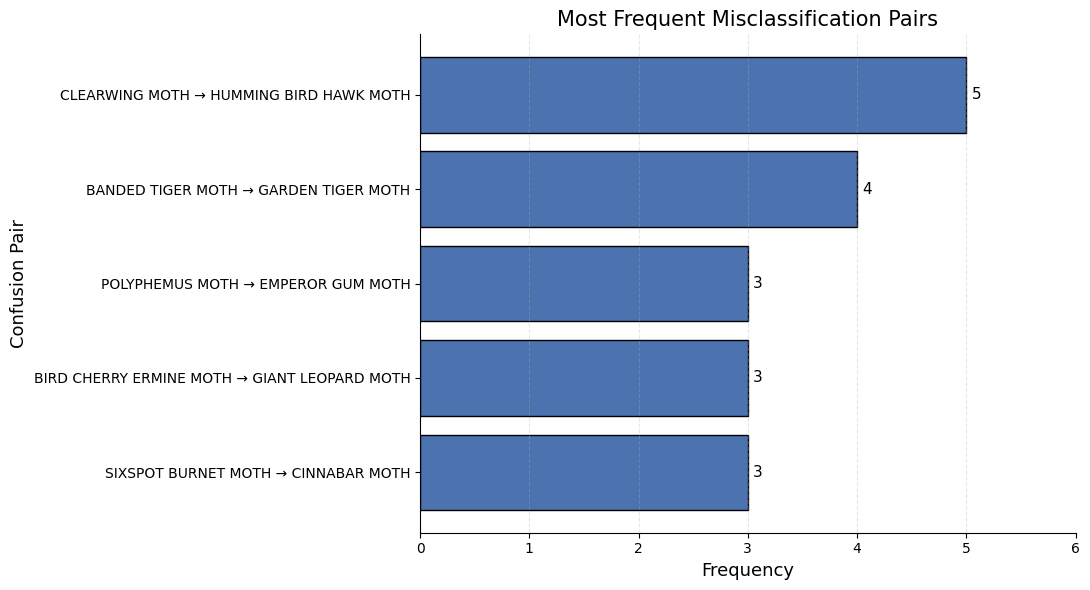

In [20]:
plot_df = confusion_table.copy()

plot_df["Confusion Pair"] = (
    plot_df["True Class"]
    + " → "
    + plot_df["Predicted Class"]
)

top5 = plot_df.sort_values(
    by="Frequency",
    ascending=False
).head(5)

top5 = top5.iloc[::-1]

plt.figure(figsize=(11,6))

bars = plt.barh(
    top5["Confusion Pair"],
    top5["Frequency"],
    color="#4C72B0",
    edgecolor="black"
)

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.05,
        bar.get_y() + bar.get_height()/2,
        str(int(width)),
        va="center",
        fontsize=11
    )

plt.xlabel("Frequency", fontsize=13)
plt.ylabel("Confusion Pair", fontsize=13)
plt.title("Most Frequent Misclassification Pairs", fontsize=15)

plt.xticks(range(0, top5["Frequency"].max() + 2))

plt.grid(axis="x", linestyle="--", alpha=0.3)

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    "Top5_ConfusionPairs.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Species Error Frequency

In [9]:
species_counter = Counter()

# 统计每个 True Class 被误分类的次数
for model_name, data in all_predictions.items():

    y_true = data["y_true"]
    y_pred = data["y_pred"]

    for t, p in zip(y_true, y_pred):
        if t != p:
            species_counter[t] += 1

rows = []

for species_id, count in species_counter.items():

    rows.append({
        "Species": class_names[species_id],
        "Misclassifications": count
    })

species_error_df = pd.DataFrame(rows)

species_error_df = species_error_df.sort_values(
    by="Misclassifications",
    ascending=False
)

species_error_df.reset_index(drop=True, inplace=True)

species_error_df

,Species,Misclassifications
0,CLEARWING MOTH,8
1,POLYPHEMUS MOTH,7
2,BANDED TIGER MOTH,5
3,BIRD CHERRY ERMINE MOTH,4
4,HUMMING BIRD HAWK MOTH,4
5,ARCIGERA FLOWER MOTH,4
6,SIXSPOT BURNET MOTH,4
7,WHITE LINED SPHINX MOTH,3
8,HERCULES MOTH,2
9,GARDEN TIGER MOTH,2


In [10]:
species_error_df.to_csv(
    "Species_Error_Frequency.csv",
    index=False
)

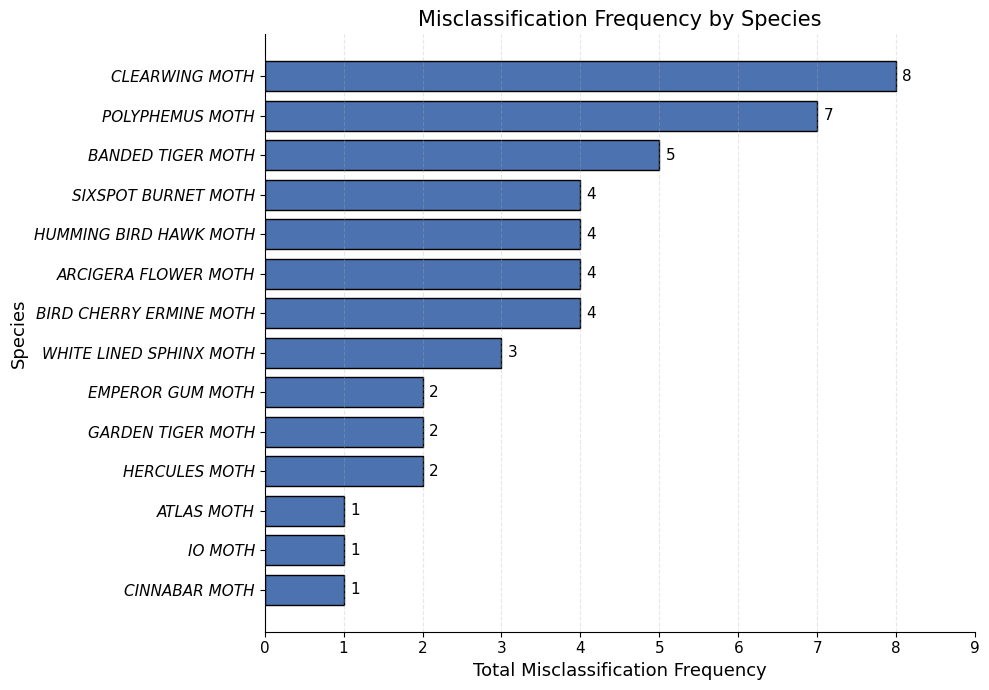

In [18]:
# 从小到大排序，画水平柱状图
plot_df = species_error_df.sort_values(
    by="Misclassifications",
    ascending=True
)

plt.figure(figsize=(10,7))

bars = plt.barh(
    plot_df["Species"],
    plot_df["Misclassifications"],
    color="#4C72B0",          # 深蓝色
    edgecolor="black",
    height=0.75
)

# 在柱子末尾添加数值
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.08,
        bar.get_y() + bar.get_height()/2,
        f"{int(width)}",
        va="center",
        fontsize=11
    )

plt.xlabel("Total Misclassification Frequency", fontsize=13)
plt.ylabel("Species", fontsize=13)
plt.title("Misclassification Frequency by Species", fontsize=15)

plt.xticks(fontsize=11)
plt.yticks(fontsize=11, fontstyle='italic')

plt.grid(axis="x", linestyle="--", alpha=0.3)

# 去掉上边框和右边框
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# 给右侧数字留一点空间
plt.xlim(0, plot_df["Misclassifications"].max() + 1)

plt.tight_layout()

plt.savefig(
    "Species_Error_Frequency.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()